# Cassandra Report: OCC2 09-earthquakes

 - Klink, Carl
 - Lefebvre, Romain
 - Matthews, Louis-Marie
 - Muller, Julie

> **All the code of this notebook was run in an environment running Python and Cassandra on Linux. In particular, a Docker container was used that was running Cassandra. See the appendices for the `docker-compose.yml` definition.**

## Dataset preparation

We are working with the `earthquakes_big.geojson.json` dataset. Since this is a JSON file, we will first explore what it contains with Pandas, and convert it to an appropriate format before uploading it into a Cassandra table.

In [1]:
JSON_FILENAME = 'earthquakes_big.geojson.json'

In [2]:
import pandas as pd
from datetime import datetime

Let’s read our file.

In [3]:
df = pd.read_json(JSON_FILENAME, lines=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7669 entries, 0 to 7668
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   type        7669 non-null   object
 1   properties  7669 non-null   object
 2   geometry    7669 non-null   object
 3   id          7669 non-null   object
dtypes: object(4)
memory usage: 239.8+ KB


We have 7669 entries, *i.e.* lines. This will be important for later checking.

We notice the type column is always equal to "Feature". Indeed:

In [4]:
df['type'].unique()

array(['Feature'], dtype=object)

So we can drop it.

In [5]:
df.drop('type', axis=1, inplace=True)

### Nested types

We notice some types are nested (`properties` and `geometry`). We can flatten the data frame.

In [6]:
df_properties = pd.json_normalize(df['properties'])
df_geometry = pd.json_normalize(df['geometry'])

#### "df_properties"

We will first check to see if there are any column that only holds one value, meaning we can discard it.

In [7]:
def find_uniques_per_column(df: pd.DataFrame):
    return df.apply(lambda col: len(col.unique()))

find_uniques_per_column(df_properties)

mag         214
place      4591
time       7653
updated    7669
tz           29
url        7669
detail     7669
felt         53
cdi          35
mmi          82
alert         3
status        4
tsunami       2
sig         216
net          13
code       7669
ids        7669
sources      54
types       138
nst         176
dmin       1237
rms         364
gap         290
magType      16
type          3
dtype: int64

We find no column that only holds one value. This also means we can rest assured there is no column either completely empty (which would amount to one unique value).

Let’s now take a look at what a random row may look like.

In [8]:
df_properties.iloc[0]

mag                                                      0.8
place                              6km W of Cobb, California
time                                         1370259968000.0
updated                                        1370260630761
tz                                                      -420
url        http://earthquake.usgs.gov/earthquakes/eventpa...
detail     http://earthquake.usgs.gov/earthquakes/feed/v1...
felt                                                     NaN
cdi                                                      NaN
mmi                                                      NaN
alert                                                   None
status                                             AUTOMATIC
tsunami                                                  NaN
sig                                                       10
net                                                       nc
code                                                72001620
ids                     

Let’s now look at the `time` and `updated` columns:

In [9]:
df_properties[['time', 'updated']].describe()

,time,updated
count,7.668000e+03,7.669000e+03
mean,1.368889e+12,1.369121e+12
std,7.049092e+08,7.031888e+08
min,1.367670e+12,1.367684e+12
25%,1.368265e+12,1.368561e+12
50%,1.368884e+12,1.369165e+12
75%,1.369445e+12,1.369775e+12
max,1.370260e+12,1.370261e+12


They are timestamps in milliseconds (they have 13 digits). We can convert them to the corresponding type. ([Cassandra stores timestamps as 64-bit ints.](https://docs.datastax.com/en/cql-oss/3.1/cql/cql_reference/timestamp_type_r.html.))

In [10]:
df_properties['time'] = df_properties['time'].astype(pd.Int64Dtype())
df_properties['updated'] = df_properties['updated'].astype(pd.Int64Dtype())

But we still don’t know what is the format of `tz`, as they are not timezones. It is difficult to convert a US area code to a timezone, and this is out of scope of this project. So, we will discard the `tz` column and instead extract the timezone from the coordinates of the earthquake that are available in `df_geometry`.

#### "df_geometry"

Let’s take a look at what a row looks like.

In [11]:
df_geometry.iloc[0]

type                             Point
coordinates    [-122.7955, 38.8232, 3]
Name: 0, dtype: object

We notice the `type` column always hold the same value.

In [12]:
df_geometry['type'].unique()

array(['Point'], dtype=object)

So we can drop the `type` column.

In [13]:
df_geometry.drop('type', axis=1, inplace=True)

Now we can extract the timezone from the coordinates (see the remark about timezones in the section about `df_properties`).

In [14]:
import pytz

from timezonefinder import TimezoneFinder

tf = TimezoneFinder()

# This is a file we created to extract the UTC timezone from a timezone name
timezones_df = pd.read_json('timezones.json')

def find_tz_offset(tz_name):
    """Get the offset from the name
    """
    row = timezones_df[timezones_df['utc'].apply(lambda x: tz_name in x)]
    if len(row) > 0:
        return row.iloc[0]['offset']
    else:
        return 0

tf.timezone_names
tz_names = {}
for tz_name in tf.timezone_names:
    tz_names[tz_name] = find_tz_offset(tz_name)

# print(tf.timezone_at(lng=df_geometry['coordinates'], lat=first_point))
df_offsets = df_geometry['coordinates'].apply(lambda x: find_tz_offset(tf.timezone_at(lng=x[0], lat=x[1])))
df_offsets

0      -7.0
1      -7.0
2      -8.0
3      -7.0
4      -8.0
       ... 
7664   -8.0
7665   -7.0
7666   -7.0
7667   -8.0
7668    9.0
Name: coordinates, Length: 7669, dtype: float64

### Final DataFrame cleaning

Now we can convert `time` and `updated` to UTC as timestamps should be.

In [15]:
df_properties['time'] = (df_properties['time'] + df_offsets * 60 * 60).astype(pd.Int64Dtype())
df_properties['updated'] = (df_properties['updated'] + df_offsets * 60 * 60).astype(pd.Int64Dtype())

We can merge all this in a flattened dataframe.

In [16]:
merged_df = pd.concat([df.drop(['properties', 'geometry'], axis=1), df_properties, df_geometry], axis=1)

By listing all unique values of each column, we can infer the desired type.

In [17]:
merged_df['alert'].unique()

array([None, 'green', 'yellow'], dtype=object)

In [18]:
merged_df['code'].unique()

array(['72001620', '72001615', '10729211', ..., '71985246', '10709349',
       '2013pucw'], shape=(7669,), dtype=object)

And so on and so on. After checking the type of values for all columns, we can apply the desired type.

In [19]:
merged_df[['alert', 'code', 'detail', 'id', 'magType', 'place', 'net', 'url', 'status', 'type']] = merged_df[['alert', 'code', 'detail', 'id', 'magType', 'place', 'net', 'url', 'status', 'type']].astype(pd.StringDtype())
merged_df['time'] = merged_df['time'].astype(pd.Int64Dtype())
merged_df['types'] = merged_df['types'].apply(lambda x: x[1:-1].split(','))
merged_df['sources'] = merged_df['sources'].apply(lambda x: x[1:-1].split(','))
merged_df['ids'] = merged_df['ids'].apply(lambda x: x[1:-1].split(','))
merged_df['updated'] =  (merged_df['updated']/1000).astype('int32')

In [20]:
merged_df.rename(str.lower, axis='columns', inplace=True)
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7669 entries, 0 to 7668
Data columns (total 27 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           7669 non-null   string 
 1   mag          7668 non-null   float64
 2   place        7669 non-null   string 
 3   time         7668 non-null   Int64  
 4   updated      7669 non-null   int32  
 5   tz           7669 non-null   int64  
 6   url          7669 non-null   string 
 7   detail       7669 non-null   string 
 8   felt         801 non-null    float64
 9   cdi          801 non-null    float64
 10  mmi          91 non-null     float64
 11  alert        63 non-null     string 
 12  status       7668 non-null   string 
 13  tsunami      15 non-null     float64
 14  sig          7669 non-null   int64  
 15  net          7669 non-null   string 
 16  code         7669 non-null   string 
 17  ids          7669 non-null   object 
 18  sources      7669 non-null   object 
 19  types 

We now save our new JSON to the disk.

In [21]:
merged_df.to_json("merged_df.json", orient='records', lines=True)

### Section summary

In this section:

 1. we explored the content and the structure of our JSON, dataset,
 1. we removed columns that did not yield any data,
 1. we flattened the dataset so that there are no nested datasets,
 1. we applied the correct types so that the result is correctly encoded into JSON,
 1. and finally, we saved the new JSON file into `merged_df.json`.

## Loading the data into Cassandra

Now that we "normalized" our dataset and saved it to `merged_df.json`, we need to create a keyspace and a table, and load our dataset into the created table. We can import the data automatically into our Cassandra table using an automated tool. This tool is called DSBulk.

### Creating the keyspace and the table

From our Cassandra server (*i.e.* in our case, a Docker container, see the appendix), we first connect to our Cassandra local cluster by running `cqlsh`.

We then create and connect to the keyspace. We set the replication factor to 1 because we only have one node.

```sql
CREATE KEYSPACE ks WITH REPLICATION = { 'class': 'SimpleStrategy', 'replication_factor': 1 };

USE ks;
```

We then create a table based on our `merged_df` structure. From the information above we can derive our `CREATE TABLE` statement!

```sql
-- Create the earthquakes table
CREATE TABLE earthquakes (
    id text PRIMARY KEY,
    mag double,
    place text,
    time bigint,
    updated bigint,
    tz smallint,
    url text,
    detail text,
    felt double,
    cdi double,
    mmi double,
    alert text,
    status text,
    tsunami double,
    sig int,
    net text,
    code text,
    ids list<text>,
    sources list<text>,
    types list<text>,
    nst double,
    dmin double,
    rms double,
    gap double,
    magtype text,
    type text,
    coordinates tuple<double, double, double>
);
```

And because we only have one node and we do not need to wait for other servers’ acknowledgements:

```sql
ALTER TABLE earthquakes WITH GC_GRACE_SECONDS = 0;
```

### Installing DSBulk

We’ll then load our data into our keyspace. To do that, we will install and use DSBulk in our container.

While it is possible to import the data from JSON into Cassandra manually, doing so is much less efficient. As a result, we decided to use DSBulk, which is optimised for converting large amounts of data from a certain format, such as JSON, and storing it in Cassandra.

It could have been possible to use the `COPY` instruction instead, already included in Cassandra, but this requires an extra conversion step from JSON to CSV.

For this, we need to do in order:

1. Check we have Java installed.
1. Download DSBulk.
1. Extract it.
1. Add DSBulk to our `PATH`.
1. Reload our bash profile.

The associated commands are:

```bash
# Check we have Java installed, should return the vresion of Java
echo $JAVA_HOME

# Download and install DSBulk
wget https://github.com/datastax/dsbulk/releases/download/1.11.0/dsbulk-1.11.0.tar.gz
tar -zxvf dsbulk-1.11.0.tar.gz
mv dsbulk-1.11.0/ /opt/
echo 'PATH=/opt/dsbulk-1.11.0/bin/:$PATH' >> .profile
source .profile
```

> **As already specified at the start of the notebook, all the code and commands of this notebook must be run from the Cassandra server, such as a Docker container.**

### Loading the data from JSON into Cassandra

And we can load our dataset into Cassandra!

```bash
dsbulk load -c json -url merged_df.json -k ks -t earthquakes
```

If you get an error, check that the path to `merged_df.json` is correct.

```bash
root@0ab2710e1cf4:~# dsbulk load -c json -url src/merged_df.json -k ks -t earthquakes
Operation directory: /root/logs/LOAD_20250211-221620-280253
total | failed | rows/s | p50ms |  p99ms | p999ms | batches
7,669 |      0 |    986 | 39.96 | 526.39 | 629.15 |    1.00
Operation LOAD_20250211-221620-280253 completed successfully in 7 seconds.
Checkpoints for the current operation were written to checkpoint.csv.
To resume the current operation, re-run it with the same settings, and add the following command line flag:
--dsbulk.log.checkpoint.file=/root/logs/LOAD_20250211-221620-280253/checkpoint.csv
```

## Queries

For easier readability we will not put the outputs of every queries, only the shorter ones.

### Simple queries

First, we will check that we have as many entries as we had in the original JSON (checked at the very beginning of the notebook).

```sql
cqlsh:ks> SELECT count(id) FROM earthquakes;

 system.count(id)
------------------
             7669

(1 rows)

Warnings :
Aggregation query used without partition key
```

We have 7669 entries, as we had in the original JSON, which is good.

Let’s now perform **additional** queries.

1. Select the first 5 rows from the earthquakes table with basic information.
```sql
cqlsh:ks> SELECT id, mag, place, time FROM earthquakes LIMIT 5;

 id         | mag | place                                         | time
------------+-----+-----------------------------------------------+---------------
 ak10713314 | 0.9 |                   129km W of Cantwell, Alaska | 1368215933200
 ci15344617 | 2.3 |                 2km ENE of Colton, California | 1368766783500
 ak10726053 | 1.2 |                  16km WSW of Big Lake, Alaska | 1369790112200
 ak10721319 | 1.3 | 35km NW of Circle Hot Springs Station, Alaska | 1369143831200
 ci15344105 | 0.8 |            10km WNW of Calipatria, California | 1368723160800
```

2. Select some of the most devastating earthquakes.
```sql
cqlsh:ks> SELECT place, mag FROM earthquakes WHERE mag > 7 ALLOW FILTERING;

 place                    | mag
--------------------------+-----
 282km SW of Vaini, Tonga | 7.4
           Sea of Okhotsk | 8.3
```

3. Select a specific earthquake by its 'id' (efficient query since 'id' is the primary key)
```sql
cqlsh:ks> SELECT id, detail, mag  FROM earthquakes WHERE id = 'usb000hc3b';

 id         | detail                                                                     | mag
------------+----------------------------------------------------------------------------+-----
 usb000hc3b | http://earthquake.usgs.gov/earthquakes/feed/v1.0/detail/usb000hc3b.geojson | 4.7
```

4. Query the first 5 earthquakes with 'mag' greater than 5.0 and 'status' equal to 'REVIEWED'
```sql
cqlsh:ks> SELECT id, place, mag FROM earthquakes WHERE mag > 5.0 AND status = 'REVIEWED' LIMIT 2 ALLOW FILTERING;

 id         | place                                         | mag
------------+-----------------------------------------------+-----
 usb000h700 |                   12km SSW of Guabito, Panama | 5.6
 usb000gz6h | 115km SE of Petropavlovsk-Kamchatskiy, Russia | 5.1
```

5. Count the number of earthquakes with 'mag' greater than 5 (ALLOW FILTERING is inefficient and should be avoided where possible)
```sql
cqlsh:ks> SELECT COUNT(*) FROM earthquakes WHERE mag > 5 ALLOW FILTERING;

 count
-------
    99

(1 rows)

Warnings :
Aggregation query used without partition key
```

6. Query earthquakes by 'place' using the secondary index on 'place' (secondary indexes are less efficient than primary key queries but more efficient than using ALLOW FILTERING)
```sql
cqlsh:ks> SELECT id, code, detail, felt FROM earthquakes WHERE place = '6km ENE of Desert Hot Springs, California';

 id         | code     | detail                                                                     | felt
------------+----------+----------------------------------------------------------------------------+------
 ci15353289 | 15353289 | http://earthquake.usgs.gov/earthquakes/feed/v1.0/detail/ci15353289.geojson | null
```

### Hard query

We will attempt to get the average magnitude by place.

> ! **We will define custom user functions. Those are disabled in Cassandra by default. If you receive an error, set `user_defined_functions_enabled` is set to `true` in `/etc/cassandra/cassandra.yaml`, then restart Cassandra.**

We first define a function to count and sum of the magnitudes at each row:

```sql
CREATE OR REPLACE FUNCTION magAvgState(state tuple<int, double>, val double)
CALLED ON NULL INPUT 
RETURNS tuple<int, double> 
LANGUAGE java AS '
    if (val != null) {
        state.setInt(0, state.getInt(0) + 1);  // Increment count
        state.setDouble(1, state.getDouble(1) + val.doubleValue());  // Add magnitude
    }
    return state;
';
```

We define a function to compute the average:

```sql
CREATE OR REPLACE FUNCTION magAvgFinal(state tuple<int, double>)
CALLED ON NULL INPUT 
RETURNS double 
LANGUAGE java AS '
    if (state.getInt(0) == 0) return null;  // Avoid division by zero
    return state.getDouble(1) / state.getInt(0);
';  
```

We define all the aggregation process:

```sql
CREATE AGGREGATE IF NOT EXISTS average_mag (double)
SFUNC magAvgState 
STYPE tuple<int, double> 
FINALFUNC magAvgFinal 
INITCOND (0,0.0);
```

And we can get the average magnitude by place.

```sql
cqlsh:ks> SELECT place, average_mag(mag) FROM earthquakes GROUP BY id LIMIT 10;

 place                                         | ks.average_mag(mag)
-----------------------------------------------+---------------------
                   129km W of Cantwell, Alaska |                 0.9
                 2km ENE of Colton, California |                 2.3
                  16km WSW of Big Lake, Alaska |                 1.2
 35km NW of Circle Hot Springs Station, Alaska |                 1.3
            10km WNW of Calipatria, California |                 0.8
             6km NW of The Geysers, California |                 0.5
           5km SW of Hamilton City, California |                 1.9
              8km NW of Calipatria, California |                 0.4
        7km WNW of Alberto Oviedo Mota, Mexico |                   3
            12km WNW of Greenville, California |                 1.5

(10 rows)

Warnings :
Aggregation query used without partition key
```

### Complex queries

#### Earthquake Data Denormalization by Magnitude Range

Step 1: Normalize Data Using Python

The following Python script will help us create the denormalized table to categorize earthquakes into magnitude buckets:

```python
import pandas as pd

input_file = "merged_df.json"
output_file = "earthquakes_by_mag_range.json"

# Read JSON data efficiently with Pandas
df = pd.read_json(input_file, lines=True)

# Convert mag to numeric (NaN for invalid values)
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')

# Create mag_bucket using vectorized operations
df['mag_bucket'] = (df['mag'].dropna()
                    .astype(int)
                    .astype(str) + '-' + (df['mag'].dropna().astype(int) + 1).astype(str))

# Filter valid entries (both mag_bucket and id present)
valid_df = df.dropna(subset=['mag_bucket', 'id'])

# Select and order columns
result_df = valid_df[['mag_bucket', 'id', 'mag']]

# Save as JSON lines
result_df.to_json(output_file, orient='records', lines=True)

print(f"Transformed data saved to {output_file}")
```

Step 2: Create Cassandra Table

The following CQL command creates a Cassandra table `earthquakes_by_mag_range` to store earthquake data based on magnitude range.

```sql
CREATE TABLE earthquakes_by_mag_range (
  mag_bucket TEXT,
  id TEXT,
  mag FLOAT,
  PRIMARY KEY ((mag_bucket), id)
);
```

Step 3: Insert Data Using DSBulk

We then use DSBulk to fill the table with the data from the python code.

```sh
dsbulk load -k ks -c json -t earthquakes_by_mag_range -f earthquakes_by_mag_range.json -m "mag_bucket=mag_bucket,id=id,mag=mag"
```

Step 4: Query Earthquake Data by Magnitude Range

The following CQL query counts the number of earthquakes grouped by magnitude range:

```sql
SELECT mag_bucket, COUNT(*) 
FROM earthquakes_by_mag_range 
GROUP BY mag_bucket;
```

Step 5: Query Output

```sql
 mag_bucket | count
------------+-------
        3-4 |   228
        2-3 |  1188
```

#### Earthquake Data Processing and Analysis

Step 1: Transforming JSON Data

We use a Python script to extract and reformat earthquake data, specifically extracting geolocation coordinates and magnitudes from a JSON file.

Python code:

```python
import pandas as pd

input_file = "merged_df.json"
output_file = "earthquakes_by_depth.json"

# Read JSON data directly into DataFrame
df = pd.read_json(input_file, lines=True)

# Split coordinates into separate columns using vectorized operations
df[['longitude', 'latitude', 'depth']] = pd.DataFrame(
    df['coordinates'].tolist(),  # Convert coordinates lists to DataFrame
    index=df.index
)

# Select and reorder required columns
transformed_df = df[['longitude', 'latitude', 'depth', 'id', 'mag']]

# Save to JSON lines format
transformed_df.to_json(output_file, orient='records', lines=True)

print(f"Transformed data saved to {output_file}")
```

Step 2: Creating the Cassandra Table

We then create a Cassandra table to store earthquake data based on depth.

The CQL query to create the table is:

```sql
CREATE TABLE earthquakes_by_depth (
  depth FLOAT,
  id TEXT,
  longitude FLOAT,
  latitude FLOAT,
  mag FLOAT,
  PRIMARY KEY (depth, id)
);
```

Step 3: We load the data into Cassandra.

We use DSBulk to load the transformed JSON data into Cassandra.

```bash
dsbulk load -c json -url earthquakes_by_geolocation.json -k ks -t earthquakes_by_depth
```

Step 4: We query the data from Cassandra.

We execute the following query to analyze earthquakes by depth:

```sql
SELECT 
  depth, 
  COUNT(*) AS earthquake_count,  -- Counts the number of earthquakes at each depth
  MIN(mag) AS min_magnitude, 
  MAX(mag) AS max_magnitude, 
  AVG(mag) AS avg_magnitude 
FROM earthquakes_by_depth 
GROUP BY depth;
```

The query returns the following result:

```sql
depth     | earthquake_count | min_magnitude | max_magnitude | avg_magnitude
-----------+------------------+---------------+---------------+---------------
      96.7 |                1 |           2.7 |           2.7 |           2.7
      57.5 |                1 |           1.8 |           1.8 |           1.8
        20 |               14 |           0.9 |           6.2 |          2.55
       155 |                1 |           4.3 |           4.3 |           4.3
      82.3 |                2 |           1.3 |           1.5 |           1.4
        45 |                4 |           1.1 |           4.8 |          2.55
      35.2 |                3 |           4.2 |           4.3 |       4.26667
      43.8 |                6 |           1.4 |             5 |           3.2
```

## Member contributions

All four members contributed equally to this work.

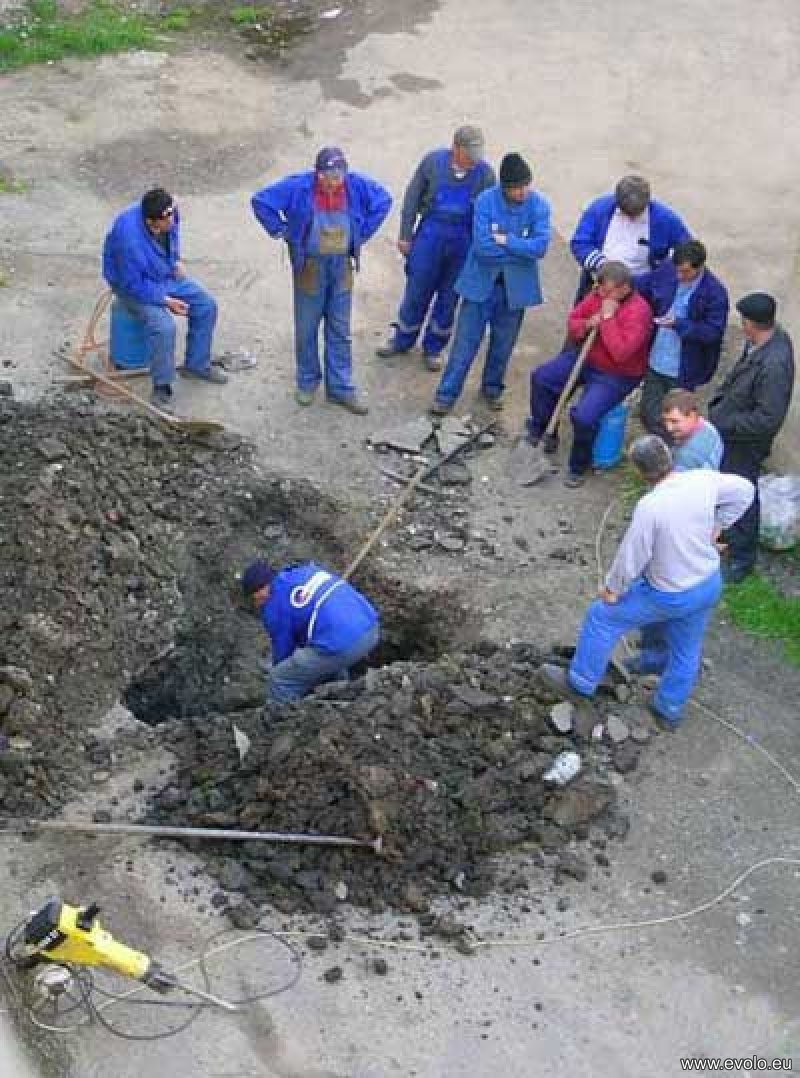

## Appendices

### Docker container definition

This is the `docker-compose.yml` file that was used to generate the container on which all the code of this project was run. [It is part of our Git repository.](https://github.com/matthewslouismarie/cas-sans-drap)

```yaml
services:
    cassandra:
        image: cassandra:latest
        ports:
        - 7000:7000
        - 7001:7001
        - 7199:7199
        - 9042:9042
        - 9160:9160
        healthcheck:
        test: ["CMD-SHELL", "[ $$(nodetool statusgossip) = running ]"]
        interval: 30s
        timeout: 10s
        retries: 5
        volumes:
        - ./src:/root/src
```